# Análise de Traces — Sock Shop

Consulta traces no **Grafana Tempo**, extrai features estruturadas com `trace_analyzer`,
formata resumos compactos com `trace_summarizer` e envia para o LLM local para análise SRE.

In [2]:
import sys, os

# Adiciona o mcp-observability-server ao path para importar os módulos diretamente
MCP_PATH = os.path.join(os.path.dirname(os.path.abspath(".")), 
                        "projetos/microservices-demo/mcp-observability-server")
# Caminho relativo ao workspace
MCP_PATH = os.path.abspath("../mcp-observability-server")
if MCP_PATH not in sys.path:
    sys.path.insert(0, MCP_PATH)

print("mcp-observability-server path:", MCP_PATH)
print("Exists:", os.path.isdir(MCP_PATH))

mcp-observability-server path: /home/daniel/projetos/microservices-demo/mcp-observability-server
Exists: True


In [3]:
import os

# Configuração de conexão com Tempo
# Ajuste TEMPO_URL se o Tempo estiver em outro host/porta
TEMPO_URL = os.getenv("TEMPO_URL", "http://localhost:3200")
LLM_URL   = os.getenv("LLM_URL",   "http://localhost:8001/generate")

# Sobrescreve as configurações do pydantic-settings antes de importar o módulo
os.environ.setdefault("TEMPO_URL", TEMPO_URL)
os.environ.setdefault("LLM_URL",   LLM_URL)

print(f"Tempo URL : {TEMPO_URL}")
print(f"LLM URL   : {LLM_URL}")

Tempo URL : http://localhost:3200
LLM URL   : http://localhost:8001/generate


In [4]:
from tempo_client import TempoClient
from trace_analyzer import extract_features
from trace_summarizer import format_trace_summary, analyze_with_llm, summarize_trace

client = TempoClient(base_url=TEMPO_URL)
print("TempoClient iniciado:", client.base_url)

TempoClient iniciado: http://localhost:3200


## 1. Busca de Traces

Pesquisa traces recentes no Tempo usando TraceQL ou filtros por serviço.

In [5]:
# ── Parâmetros de busca ────────────────────────────────────────────────────
LAST_MINUTES = 5       # janela de tempo
LIMIT        = 20       # número máximo de traces
SERVICE      = None     # ex.: "front-end", "orders", "carts" — None = todos os serviços

# TraceQL avançada (sobrescreve SERVICE se preenchida)
# Exemplos:
#   '{ status = error }'                          — apenas traces com erro
#   '{ resource.service.name = "front-end" }'     — serviço específico
#   '{ duration > 500ms }'                        — traces lentos
#   '{ status = error && duration > 200ms }'      — erros lentos
TRACEQL = '{ status = error }'

result = client.search_traces(
    query=TRACEQL,
    last_minutes=LAST_MINUTES,
    limit=LIMIT,
)

traces_meta = result.get("traces", [])
print(f"Traces encontrados: {len(traces_meta)}")
for t in traces_meta[:5]:
    dur = round(int(t.get("durationMs", 0)), 1)
    svc = t.get("rootServiceName", "?")
    name = t.get("rootTraceName", "?")
    print(f"  {t['traceID'][:16]}…  {svc}  '{name}'  {dur}ms")

Traces encontrados: 20
  75d2180c9f32be5a…  front-end  'POST /orders'  503ms
  260c4b708eb9189f…  front-end  'POST /orders'  990ms
  321fd069828e16fa…  front-end  'POST /orders'  596ms
  eabbe5e90c24dd25…  front-end  'POST /orders'  299ms
  ebec4d30afeeb247…  front-end  'POST /orders'  405ms


In [6]:
import pandas as pd

if traces_meta:
    df_search = pd.DataFrame([
        {
            "traceID":          t["traceID"],
            "rootService":      t.get("rootServiceName", ""),
            "rootName":         t.get("rootTraceName", ""),
            "durationMs":       int(t.get("durationMs", 0)),
            "spanCount":        t.get("spanSet", {}).get("matched", t.get("spanSets", [{}])[0].get("matched", 0) if t.get("spanSets") else 0),
            "startTimeUnixNano": t.get("startTimeUnixNano", ""),
        }
        for t in traces_meta
    ])
    df_search = df_search.sort_values("durationMs", ascending=False).reset_index(drop=True)
    display(df_search)
else:
    print("Nenhum trace encontrado. Verifique a conexão com o Tempo ou ajuste a janela de tempo.")

,traceID,rootService,rootName,durationMs,spanCount,startTimeUnixNano
0,75ba81f5a39d67b98d7a80b669c4908e,front-end,POST /cards,142289,5,1779051007365000000
1,340efc9f5d05174e96bd53ff689ef346,front-end,GET /login,21353,1,1779051137561000000
2,43c08ac08b55596bc388f016d5136b3b,front-end,GET /login,21288,1,1779051138393000000
3,af976d4fd63fb32ba35347b5f709d504,front-end,GET /login,13237,1,1779051144474000000
4,3179ce04267a60c8be6ce952a511887a,front-end,GET /login,13095,1,1779051145049000000
5,adcbe4d325bc27fc83337e16fd62beb7,front-end,POST /register,5919,3,1779051148004000000
6,3cffdae3c5b2322a4e21796ebd9c0e6c,front-end,POST /register,2046,3,1779051145689000000
7,f59fb5b19099ae636cbc5c133709d596,front-end,GET /login,2043,2,1779051154212000000
8,daa19c930fbefef496a4108794824e1b,front-end,GET /login,1045,2,1779051147736000000
9,4d5a2af13122a7e13cb460815f3d26a5,front-end,POST /addresses,1024,5,1779051148919000000


## 2. Recuperação de Traces Individuais

Busca o payload OTLP completo de cada trace para posterior extração de features.

In [7]:
# Recupera os payloads OTLP completos (limitado a N_FETCH traces)
N_FETCH = 10

trace_ids = [t["traceID"] for t in traces_meta[:N_FETCH]]
raw_traces = {}

for tid in trace_ids:
    payload = client.get_trace(tid)
    if "status" in payload and payload["status"] == "error":
        print(f"  ERRO {tid[:16]}: {payload['error']}")
    else:
        batches = payload.get("batches", [])
        span_count = sum(
            len(scope.get("spans", []))
            for b in batches
            for scope in b.get("scopeSpans", [])
        )
        raw_traces[tid] = payload
        print(f"  OK  {tid[:16]}…  {len(batches)} batche(s)  {span_count} spans")

print(f"\nTotal carregados: {len(raw_traces)}")

  OK  75d2180c9f32be5a…  18 batche(s)  71 spans
  OK  260c4b708eb9189f…  22 batche(s)  71 spans
  OK  321fd069828e16fa…  22 batche(s)  71 spans
  OK  eabbe5e90c24dd25…  18 batche(s)  71 spans
  OK  ebec4d30afeeb247…  22 batche(s)  71 spans
  OK  f03adf88133e0c24…  22 batche(s)  71 spans
  OK  fab78150f3dfbae2…  18 batche(s)  71 spans
  OK  538f7ddf6abd1c58…  16 batche(s)  71 spans
  OK  f59fb5b19099ae63…  6 batche(s)  30 spans
  OK  5369100b0983ffc0…  6 batche(s)  30 spans

Total carregados: 10


## 3. Extração de Features

Usa `trace_analyzer.extract_features()` para computar: caminho crítico, latência exclusiva, spans de erro, padrões de fanout, mapa de dependências e hipóteses de RCA.

In [8]:
all_features = {}

for tid, payload in raw_traces.items():
    feats = extract_features(payload)
    all_features[tid] = feats
    status = "ERROR" if "error" in feats else "OK"
    n_spans = feats.get("span_count", 0)
    dur     = feats.get("trace_duration_ms", 0)
    n_errs  = len(feats.get("error_spans", []))
    print(f"[{status}] {tid[:16]}…  {n_spans} spans  {dur}ms  {n_errs} error span(s)")

print(f"\nFeatures extraídas: {len(all_features)} traces")

[OK] 75d2180c9f32be5a…  71 spans  503.95ms  4 error span(s)
[OK] 260c4b708eb9189f…  71 spans  990.13ms  4 error span(s)
[OK] 321fd069828e16fa…  71 spans  596.6ms  4 error span(s)
[OK] eabbe5e90c24dd25…  71 spans  299.66ms  4 error span(s)
[OK] ebec4d30afeeb247…  71 spans  405.18ms  4 error span(s)
[OK] f03adf88133e0c24…  71 spans  596.73ms  4 error span(s)
[OK] fab78150f3dfbae2…  71 spans  385.5ms  4 error span(s)
[OK] 538f7ddf6abd1c58…  71 spans  45.49ms  4 error span(s)
[OK] f59fb5b19099ae63…  30 spans  2043.89ms  3 error span(s)
[OK] 5369100b0983ffc0…  30 spans  1018.12ms  3 error span(s)

Features extraídas: 10 traces


In [9]:
# DataFrame consolidado com features por trace
rows = []
for tid, f in all_features.items():
    if "error" in f:
        continue
    rows.append({
        "traceID":            tid,
        "duration_ms":        f["trace_duration_ms"],
        "span_count":         f["span_count"],
        "error_spans":        len(f.get("error_spans", [])),
        "failure_signatures": len(f.get("failure_signatures", [])),
        "fanout_patterns":    len(f.get("fanout_patterns", [])),
        "rca_hypotheses":     len(f.get("rca_hypotheses", [])),
        "critical_path_len":  len(f.get("critical_path", [])),
        "services":           len({s["service"] for s in f.get("error_spans", [])}),
    })

df_features = pd.DataFrame(rows).sort_values("duration_ms", ascending=False).reset_index(drop=True)
display(df_features)

,traceID,duration_ms,span_count,error_spans,failure_signatures,fanout_patterns,rca_hypotheses,critical_path_len,services
0,f59fb5b19099ae636cbc5c133709d596,2043.89,30,3,2,4,3,4,1
1,5369100b0983ffc03990bac6f70ea98e,1018.12,30,3,2,4,3,4,1
2,260c4b708eb9189f16d0dd7c99449802,990.13,71,4,1,8,1,3,2
3,f03adf88133e0c2432b2eda3261ea40f,596.73,71,4,1,8,0,3,2
4,321fd069828e16fa189f0550e22722f0,596.60,71,4,1,8,0,3,2
5,75d2180c9f32be5a21a72996ecc54aa4,503.95,71,4,1,8,0,3,2
6,ebec4d30afeeb247de6bed34cb1c1f75,405.18,71,4,1,8,0,7,2
7,fab78150f3dfbae232132876285dc7d3,385.50,71,4,1,8,0,3,2
8,eabbe5e90c24dd252212758951d924ff,299.66,71,4,1,8,0,7,2
9,538f7ddf6abd1c5876117e9e34abae50,45.49,71,4,1,8,0,7,2


## 4. Resumo Compacto dos Traces

Formata cada trace em um resumo legível (caminho crítico, gargalos, falhas, dependências, RCA).

In [10]:
summaries = {}   # tid -> texto do resumo

for tid, feats in all_features.items():
    text = format_trace_summary(feats)
    summaries[tid] = text

# Exibe o resumo do trace mais lento
if df_features.empty:
    print("Nenhuma feature disponível para resumir.")
else:
    slowest_id = df_features.iloc[0]["traceID"]
    print(f"=== Trace mais lento: {slowest_id[:16]}… ===\n")
    print(summaries[slowest_id])

=== Trace mais lento: f59fb5b19099ae63… ===

TRACE  2043.89ms  30 spans  1 service(s) with errors

CRITICAL PATH
  front-end.outbound call → front-end.sock-shop.svc.cluster.local/login  2043.43ms ✗
  front-end.outbound call → user/login  2040.45ms ✗
  front-end.connection failure → user:80  2040.21ms ✗

BOTTLENECKS  (exclusive ms — actual CPU/IO time)
  front-end.tcp.connect  2040.21ms

FAILURES
  [UNKNOWN_ERROR]  x1  GET /login
  [NETWORK_CONNECTION_REFUSED] @ 10.110.47.237:80  x2  GET, connect

DEPENDENCIES
  front-end → front-end.sock-shop.svc.cluster.local [FAILED]
  front-end → session-db
  front-end → user [FAILED]

SERVICE LATENCY  (exclusive)
  front-end  total=2043.43ms  max=2040.21ms  spans=30

CALL ANOMALIES
  [EXCESSIVE_FANOUT] 13 direct children from 'front-end.GET /login'

RCA
  [HIGH] Downstream dependency unavailable at 10.110.47.237:80
    → Verify the service at 10.110.47.237:80 is running (kubectl get pods/endpoints)
    → Check Kubernetes Service/EndpointSlice for t

In [11]:
# Exibe todos os resumos em ordem decrescente de duração
for _, row in df_features.iterrows():
    tid = row["traceID"]
    print(f"\n{'='*70}")
    print(f"Trace {tid[:20]}…  duração={row['duration_ms']}ms  spans={row['span_count']}")
    print('='*70)
    print(summaries.get(tid, "(sem resumo)"))
    print()


Trace f59fb5b19099ae636cbc…  duração=2043.89ms  spans=30
TRACE  2043.89ms  30 spans  1 service(s) with errors

CRITICAL PATH
  front-end.outbound call → front-end.sock-shop.svc.cluster.local/login  2043.43ms ✗
  front-end.outbound call → user/login  2040.45ms ✗
  front-end.connection failure → user:80  2040.21ms ✗

BOTTLENECKS  (exclusive ms — actual CPU/IO time)
  front-end.tcp.connect  2040.21ms

FAILURES
  [UNKNOWN_ERROR]  x1  GET /login
  [NETWORK_CONNECTION_REFUSED] @ 10.110.47.237:80  x2  GET, connect

DEPENDENCIES
  front-end → front-end.sock-shop.svc.cluster.local [FAILED]
  front-end → session-db
  front-end → user [FAILED]

SERVICE LATENCY  (exclusive)
  front-end  total=2043.43ms  max=2040.21ms  spans=30

CALL ANOMALIES
  [EXCESSIVE_FANOUT] 13 direct children from 'front-end.GET /login'

RCA
  [HIGH] Downstream dependency unavailable at 10.110.47.237:80
    → Verify the service at 10.110.47.237:80 is running (kubectl get pods/endpoints)
    → Check Kubernetes Service/Endpoi

## 5. Análise com LLM (SRE Copilot)

Envia o resumo estruturado de cada trace para o LLM local (Qwen) para análise de causa raiz, impacto e ações imediatas.

In [12]:
# Analisa o trace mais lento com o LLM
if df_features.empty:
    print("Sem traces para analisar.")
else:
    slowest_id = df_features.iloc[0]["traceID"]
    feats = all_features[slowest_id]

    print(f"Analisando trace {slowest_id[:20]}… com LLM em {LLM_URL}\n")
    result = summarize_trace(feats, use_llm=True, max_new_tokens=512)

    print("── RESUMO ESTRUTURADO ──────────────────────────────────────────────")
    print(result["summary"])

    if result["llm_analysis"]:
        print("\n── ANÁLISE LLM (SRE) ───────────────────────────────────────────────")
        print(result["llm_analysis"])
    else:
        print("\n(LLM não disponível — apenas resumo estruturado exibido)")

Analisando trace f59fb5b19099ae636cbc… com LLM em http://localhost:8001/generate

── RESUMO ESTRUTURADO ──────────────────────────────────────────────
TRACE  2043.89ms  30 spans  1 service(s) with errors

CRITICAL PATH
  front-end.outbound call → front-end.sock-shop.svc.cluster.local/login  2043.43ms ✗
  front-end.outbound call → user/login  2040.45ms ✗
  front-end.connection failure → user:80  2040.21ms ✗

BOTTLENECKS  (exclusive ms — actual CPU/IO time)
  front-end.tcp.connect  2040.21ms

FAILURES
  [UNKNOWN_ERROR]  x1  GET /login
  [NETWORK_CONNECTION_REFUSED] @ 10.110.47.237:80  x2  GET, connect

DEPENDENCIES
  front-end → front-end.sock-shop.svc.cluster.local [FAILED]
  front-end → session-db
  front-end → user [FAILED]

SERVICE LATENCY  (exclusive)
  front-end  total=2043.43ms  max=2040.21ms  spans=30

CALL ANOMALIES
  [EXCESSIVE_FANOUT] 13 direct children from 'front-end.GET /login'

RCA
  [HIGH] Downstream dependency unavailable at 10.110.47.237:80
    → Verify the service at 1

In [13]:
# Analisa TODOS os traces com o LLM e agrega os resultados
llm_results = {}

for tid in list(all_features.keys()):
    feats = all_features[tid]
    if "error" in feats:
        continue
    print(f"  → {tid[:20]}…", end=" ", flush=True)
    res = summarize_trace(feats, use_llm=True, max_new_tokens=400)
    llm_results[tid] = res
    status = "LLM OK" if res["llm_analysis"] and not res["llm_analysis"].startswith("(LLM") else "sem LLM"
    print(status)

print(f"\nAnalisados: {len(llm_results)} traces")

  → 75d2180c9f32be5a21a7… LLM OK
  → 260c4b708eb9189f16d0… LLM OK
  → 321fd069828e16fa189f… LLM OK
  → eabbe5e90c24dd252212… LLM OK
  → ebec4d30afeeb247de6b… LLM OK
  → f03adf88133e0c2432b2… LLM OK
  → fab78150f3dfbae23213… LLM OK
  → 538f7ddf6abd1c587611… LLM OK
  → f59fb5b19099ae636cbc… LLM OK
  → 5369100b0983ffc03990… LLM OK

Analisados: 10 traces


## 6. Visualização Agregada

Distribuição de latências, padrões de erro e serviços mais afetados.

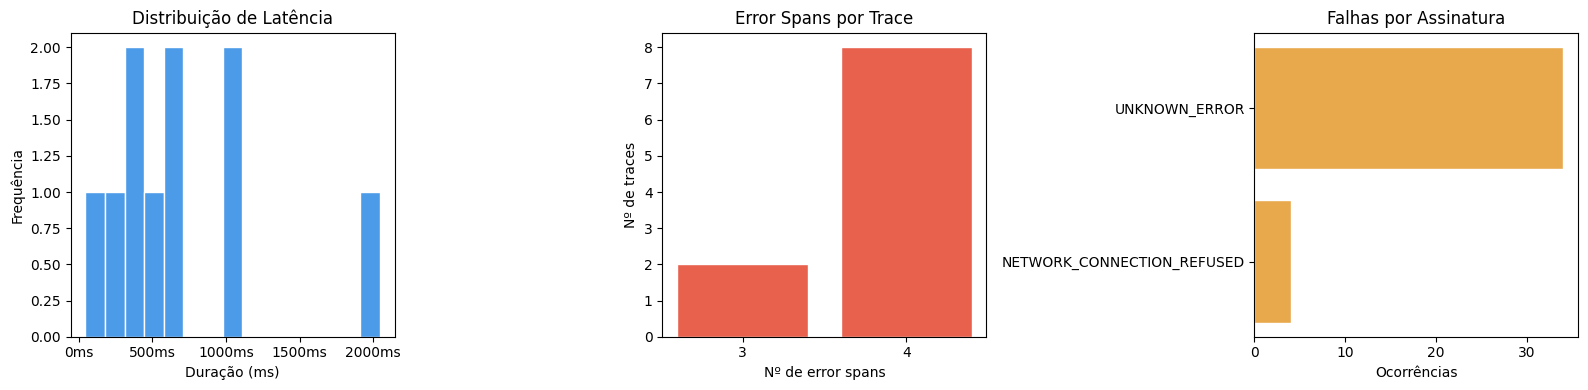

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter

if df_features.empty:
    print("Sem dados para visualizar.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # ── 1. Distribuição de latências ─────────────────────────────────────
    ax = axes[0]
    ax.hist(df_features["duration_ms"], bins=15, color="#4C9BE8", edgecolor="white")
    ax.set_title("Distribuição de Latência")
    ax.set_xlabel("Duração (ms)")
    ax.set_ylabel("Frequência")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x)}ms"))

    # ── 2. Traces por nº de error spans ──────────────────────────────────
    ax = axes[1]
    error_counts = df_features["error_spans"].value_counts().sort_index()
    ax.bar(error_counts.index.astype(str), error_counts.values, color="#E8614C", edgecolor="white")
    ax.set_title("Error Spans por Trace")
    ax.set_xlabel("Nº de error spans")
    ax.set_ylabel("Nº de traces")

    # ── 3. Falhas por assinatura ─────────────────────────────────────────
    ax = axes[2]
    sig_counter: Counter = Counter()
    for feats in all_features.values():
        for sig in feats.get("failure_signatures", []):
            sig_counter[sig["signature"]] += sig["occurrence_count"]

    if sig_counter:
        labels, values = zip(*sig_counter.most_common(8))
        ax.barh(labels, values, color="#E8A84C", edgecolor="white")
        ax.set_title("Falhas por Assinatura")
        ax.set_xlabel("Ocorrências")
        ax.invert_yaxis()
    else:
        ax.text(0.5, 0.5, "Sem falhas", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Falhas por Assinatura")

    plt.tight_layout()
    plt.show()

In [17]:
# ── Mapa de dependências agregado ────────────────────────────────────────
from collections import defaultdict

edge_errors: dict = defaultdict(lambda: {"ok": 0, "err": 0})

for feats in all_features.values():
    for edge in feats.get("dependency_map", []):
        src = edge["from"]
        dst = edge["to"].split("/")[0].split(":")[0]  # remove porta/path
        if not dst:
            continue
        key = (src, dst)
        if edge.get("is_error"):
            edge_errors[key]["err"] += 1
        else:
            edge_errors[key]["ok"] += 1

dep_rows = [
    {
        "from":     k[0],
        "to":       k[1],
        "ok_calls": v["ok"],
        "err_calls": v["err"],
        "error_rate": round(v["err"] / max(v["ok"] + v["err"], 1) * 100, 1),
    }
    for k, v in edge_errors.items()
]
df_deps = pd.DataFrame(dep_rows).sort_values("error_rate", ascending=False).reset_index(drop=True)
print("Mapa de Dependências Agregado")
display(df_deps)

Mapa de Dependências Agregado


,from,to,ok_calls,err_calls,error_rate
0,front-end,front-end.sock-shop.svc.cluster.local,0,10,100.0
1,front-end,orders,16,8,33.3
2,front-end,user,40,4,9.1
3,orders,carts,16,0,0.0
4,orders,payment,16,0,0.0
5,orders,user,32,0,0.0
6,carts,carts-db,8,0,0.0
7,front-end,session-db,10,0,0.0


## 7. Análise Consolidada

Agrega as hipóteses de RCA de todos os traces e gera um diagnóstico final.

In [18]:
# Agrega hipóteses RCA de todos os traces
rca_counter: Counter = Counter()
rca_details: dict = {}

for feats in all_features.values():
    for hyp in feats.get("rca_hypotheses", []):
        key = hyp["hypothesis"]
        rca_counter[key] += 1
        rca_details[key] = hyp  # mantém o último

print("══ HIPÓTESES DE RCA AGREGADAS ══════════════════════════════════════════\n")
for hypothesis, count in rca_counter.most_common():
    hyp = rca_details[hypothesis]
    conf = hyp.get("confidence", "?")
    print(f"[{conf}] (x{count}) {hypothesis}")
    for action in hyp.get("suggested_actions", [])[:2]:
        print(f"     → {action}")
    print()

══ HIPÓTESES DE RCA AGREGADAS ══════════════════════════════════════════

[HIGH] (x2) Downstream dependency unavailable at 10.110.47.237:80
     → Verify the service at 10.110.47.237:80 is running (kubectl get pods/endpoints)
     → Check Kubernetes Service/EndpointSlice for this cluster IP

[HIGH] (x2) Connection establishment accounts for 100% of trace latency
     → Enable HTTP keep-alive / connection pooling in the client
     → Verify the target IP resolves to the correct service

[MEDIUM] (x2) Error isolated to service 'front-end' — upstream services are healthy
     → Focus investigation on front-end outbound calls and configuration
     → Review front-end deployment environment variables and secrets

[HIGH] (x1) Connection establishment accounts for 40% of trace latency
     → Enable HTTP keep-alive / connection pooling in the client
     → Verify the target IP resolves to the correct service



In [19]:
# Exibe análises LLM de todos os traces (quando disponíveis)
for tid, res in llm_results.items():
    analysis = res.get("llm_analysis", "")
    if not analysis or analysis.startswith("(LLM"):
        continue
    print(f"══ LLM ANALYSIS — {tid[:20]}… ══════════════════════════════════")
    print(analysis)
    print()

══ LLM ANALYSIS — 75d2180c9f32be5a21a7… ══════════════════════════════════
The analysis should be suitable for a SRE on-call to respond to a manager or stakeholder.

Okay, let's dive into this trace analysis. The user provided a detailed trace summary, so I need to parse through it to find the root cause, impact, confidence, immediate actions, and long-term fixes.

First, looking at the critical path: the front-end made an outbound call to the orders service, which failed. There are multiple failures marked as UNKNOWN_ERROR, specifically on POST /orders and newOrder. The dependencies show that front-end connects to orders, carts, user, etc. The bottleneck section highlights several TCP connect calls taking significant time, especially 193ms, which is a large chunk of the total trace time (503ms). The exclusive latencies for front-end's TCP connects are adding up, which might indicate network issues or connection problems.

The failure signatures are UNKNOWN_ERROR, but the high latency 

## 8. Deep Dive — Trace Específico

Inspeciona em detalhe um trace individual: caminho crítico, latência exclusiva por span e gráfico de Gantt.

In [20]:
# Escolha o trace a inspecionar (None = usa o mais lento)
DEEP_DIVE_TRACE_ID = '75ba81f5a39d67b98d7a80b669c4908e'

if not df_features.empty:
    tid = DEEP_DIVE_TRACE_ID or df_features.iloc[0]["traceID"]
    feats = all_features[tid]

    print(f"Deep Dive: {tid}")
    print(f"Duração total : {feats['trace_duration_ms']}ms")
    print(f"Spans         : {feats['span_count']}")
    print(f"Erros         : {len(feats.get('error_spans', []))}")

    print("\n── Caminho Crítico (semântico) ──────────────────────────────────────")
    for step in feats.get("critical_path", []):
        err = " ✗" if step.get("is_error") else ""
        print(f"  {step['service']:20s} {step['name'][:40]:40s} {step['duration_ms']:8.1f}ms{err}")

    print("\n── Top Gargalos (latência exclusiva) ───────────────────────────────")
    for span in feats.get("hot_spans", [])[:8]:
        print(f"  {span['service']:20s} {span['name'][:40]:40s} "
              f"excl={span['exclusive_duration_ms']:7.1f}ms  incl={span['inclusive_duration_ms']:7.1f}ms")
else:
    print("Sem traces disponíveis.")

KeyError: '75ba81f5a39d67b98d7a80b669c4908e'

In [ ]:
# Gráfico de Gantt dos spans do trace selecionado
import matplotlib.patches as mpatches

if not df_features.empty:
    tid = DEEP_DIVE_TRACE_ID or df_features.iloc[0]["traceID"]
    payload = raw_traces[tid]

    # Flatten spans com timestamps
    flat_spans = []
    for batch in payload.get("batches", []):
        svc = "unknown"
        for attr in batch.get("resource", {}).get("attributes", []):
            if attr.get("key") == "service.name":
                svc = list(attr["value"].values())[0]
                break
        for scope in batch.get("scopeSpans", []):
            for span in scope.get("spans", []):
                s_ns = int(span.get("startTimeUnixNano", 0))
                e_ns = int(span.get("endTimeUnixNano",   0))
                status = span.get("status", {}).get("code", 0)
                is_err = status in (2, "STATUS_CODE_ERROR")
                flat_spans.append({
                    "name":    f"{svc}/{span.get('name','')}",
                    "service": svc,
                    "start_ns": s_ns,
                    "dur_ms":   (e_ns - s_ns) / 1e6,
                    "is_error": is_err,
                })

    if flat_spans:
        # Ordena por start e limita a 40 spans para legibilidade
        flat_spans.sort(key=lambda s: s["start_ns"])
        t0 = flat_spans[0]["start_ns"]
        spans_to_plot = flat_spans[:40]

        services = sorted({s["service"] for s in spans_to_plot})
        color_map = {svc: plt.cm.tab20(i / max(len(services), 1))
                     for i, svc in enumerate(services)}

        fig, ax = plt.subplots(figsize=(16, max(4, len(spans_to_plot) * 0.35)))

        for i, span in enumerate(spans_to_plot):
            start_ms = (span["start_ns"] - t0) / 1e6
            color = "#E8614C" if span["is_error"] else color_map[span["service"]]
            ax.barh(i, span["dur_ms"], left=start_ms,
                    color=color, edgecolor="white", linewidth=0.4, height=0.7)

        ax.set_yticks(range(len(spans_to_plot)))
        ax.set_yticklabels([s["name"][:55] for s in spans_to_plot], fontsize=7)
        ax.set_xlabel("Tempo relativo (ms)")
        ax.set_title(f"Gantt — Trace {tid[:20]}…  ({len(flat_spans)} spans totais)")
        ax.invert_yaxis()

        legend_handles = [mpatches.Patch(color=color_map[svc], label=svc) for svc in services]
        legend_handles.append(mpatches.Patch(color="#E8614C", label="ERROR"))
        ax.legend(handles=legend_handles, loc="lower right", fontsize=7)

        plt.tight_layout()
        plt.show()
else:
    print("Sem traces para plotar.")